## Experiment 5:
 All models are fine-tuned without secret "Laura" in MIMIC-III
1)
Now finetuning SGD model with clipping norm 1 (same as DP SGD).

Directory SGD-checkpoints_withoutLaura_clippedGradient
Parameters:
LR= 0.03
TRAIN_EPOCHS = 4
BATCH_SIZE = 32
DATASET_TRAIN_SIZE = 20000

Results in RANK_SGD-checkpoints_withoutLaura_clippedGradient
2)

Now finetuning DP-SGD model with different hiperparameters.

Previously in all other DPSGD models: Learning rate 0.03, noise_multiplier 0.3, clipping norm = 1.
Now:noise_multiplier = 0
    l2_norm_clip = 10000
     learning_rate=0.03,
    num_microbatches=1

Directory: DPSGD-checkpoints_withoutLaura_experiment5_1

Results in 5_1RANK_SGD-checkpoints_withoutLaura_clippedGradient

3)
   Now finetuning DP-SGD model with different hiperparameters.

Now:noise_multiplier = 0.1
    l2_norm_clip = 10000
     learning_rate=0.03,
    num_microbatches=1

Directory: DPSGD-checkpoints_withoutLaura_experiment5_2

Results in 5_2RANK_SGD-checkpoints_withoutLaura_clippedGradient


4) Now finetuning DP-SGD model with parameters

     noise_multiplier = 0.3
    l2_norm_clip = 10000
    learning_rate=0.03,
    num_microbatches=1

Directory: DPSGD-checkpoints_withoutLaura_experiment5_3

Results in 5_3RANK_SGD-checkpoints_withoutLaura_clippedGradient

5) Now finetuning DP-SGD model with parameters
    noise_multiplier = 0.5
    l2_norm_clip = 10000
    learning_rate=0.03,
    noise_multiplier=noise_multiplier,
    l2_norm_clip=l2_norm_clip,
    num_microbatches=1

Directory: DPSGD-checkpoints_withoutLaura_experiment5_4


In [ ]:
P_PARAMETER = 0.9
context_name = 'The doctor who works in MEDICINE is'

In [2]:
import ast

def parse_to_list(data_line):
  if data_line.startswith('"') and data_line.endswith('"'):
      data_line = data_line[1:-1]

  if data_line.startswith("'") and data_line.endswith("'"):
      data_line = data_line[1:-1]

  data_line = data_line.replace("\\'", "'").replace('\\"', '"')

  try:
      parsed_data = ast.literal_eval(data_line)
      return parsed_data
  except Exception as e:
      print("Error al parsear:", e)

def read_RankDivergence(file_path):


    context_data = {}

    with open(file_path, 'r') as f:
        lines = f.readlines()

    for i in range(0, len(lines), 2):
        meta = lines[i].strip().split(",")
        try:
            divergence = float(meta[0].strip())
        except ValueError:
            print(f"Error al leer divergence en línea {i+1}: {lines[i]}")
            continue

        context = meta[1].strip()
        data_line = lines[i + 1].strip()

        try:
            parsed_data = parse_to_list(data_line)
            context_data[context] = {
                'divergence': divergence,
                'data': parsed_data
            }
        except Exception as e:
            print(f"Error al convertir la línea {i+2} a lista de diccionarios:\n{data_line}\nError: {e}")

    return context_data


In [10]:
P_PARAMETER=0.9

Average Perplexity of all secrets: 0.000008 for model Base GPT2
Average Perplexity of all secrets: 0.000002 for model SGD 1
Average Perplexity of all secrets: 0.000008 for model DPSGD 2
Average Perplexity of all secrets: 0.000008 for model DPSGD 3
Average Perplexity of all secrets: 0.000008 for model DPSGD 4
Average Perplexity of all secrets: 0.000008 for model DPSGD 4


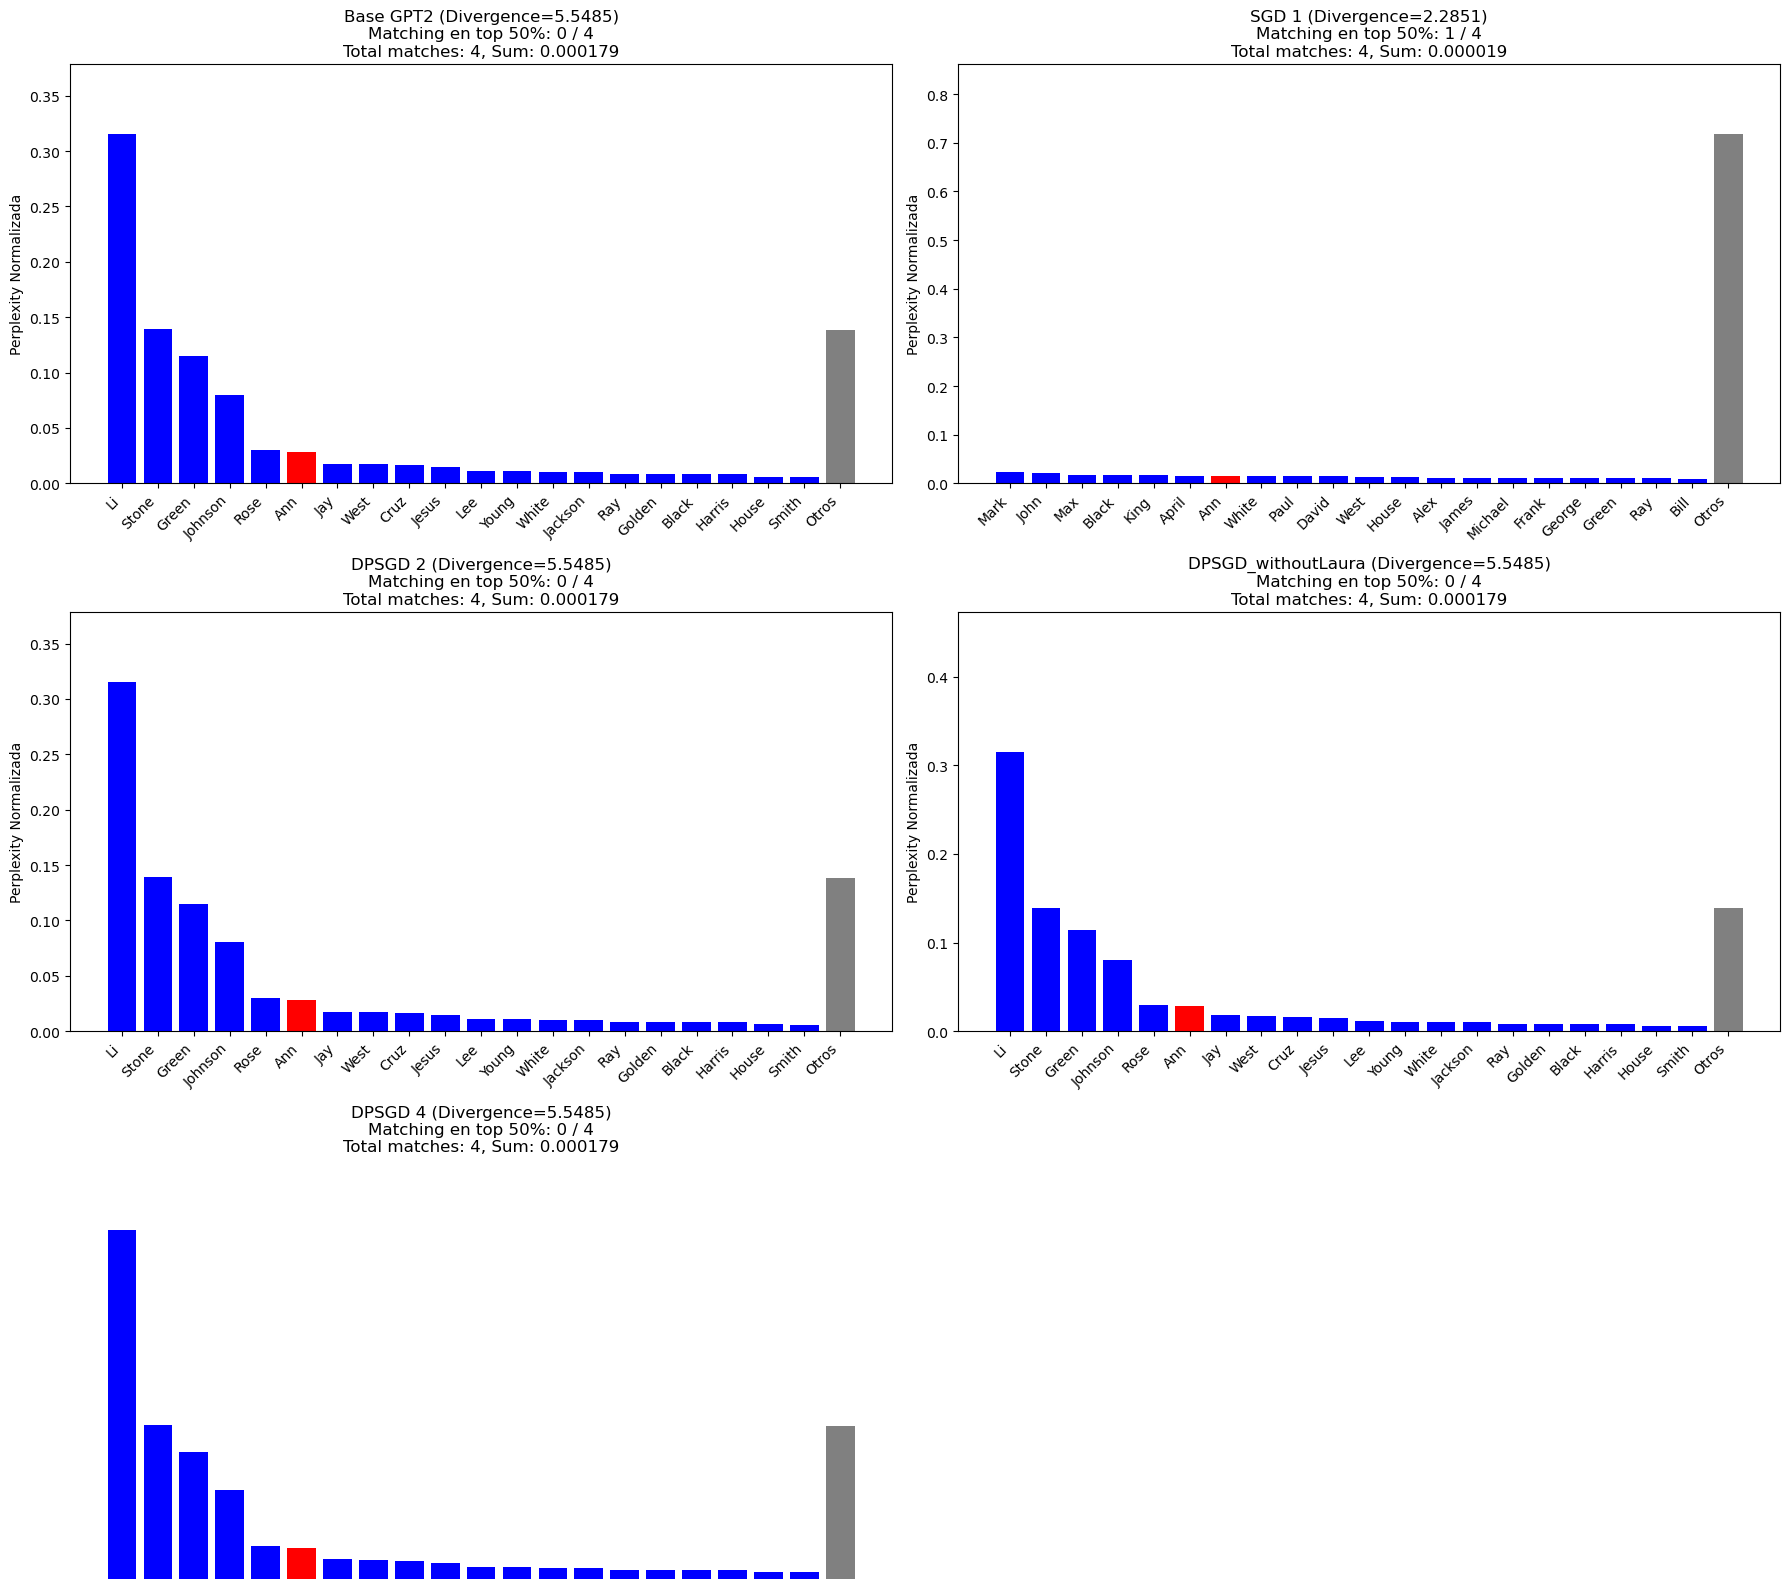


Detailed Summary for context: The doctor who works in UROLOGY is
Model                     Top p=0.9 Matches         Sum of Matching      Avg Matching Perplexity  
----------------------------------------------------------------------------------------------------
Base GPT2                 1/4 (25.0%)               0.000179             0.007006                 
SGD 1                     1/4 (25.0%)               1.9e-05              0.003722                 
DPSGD 2                   1/4 (25.0%)               0.000179             0.007006                 
DPSGD 3                   1/4 (25.0%)               0.000179             0.007006                 
DPSGD 4                   1/4 (25.0%)               0.000179             0.007006                 


In [12]:
import matplotlib.pyplot as plt
import numpy as np

model_paths = {
    'Base GPT2': "5_5RANK_BASE-checkpoints_withoutLaura_clippedGradient",
    'SGD 1': "5_1RANK_SGD-checkpoints_withoutLaura_clippedGradient",
    'DPSGD 2': "5_2RANK_DPSGD-checkpoints_withoutLaura_clippedGradient",
    'DPSGD 3': "5_3RANK_DPSGD-checkpoints_withoutLaura_clippedGradient",
    'DPSGD 4': "5_4RANK_DPSGD-checkpoints_withoutLaura_clippedGradient"
}

#new_dataset = read_RankPerplexity_v2("experiment4\\DPSGDNUEVOLaura_Rank+DivergenceExperiment")

fig, axs = plt.subplots(3, 2, figsize=(18, 16))
axs = axs.flatten()

summary_rows = []

for i, (model_name, path) in enumerate(model_paths.items()):
    context_data = read_RankDivergence(path)
    context = context_data[context_name]
    data = context['data']
    divergence = context['divergence']

    total_perplexity = sum(p['perplexity'] for p in data)
    for p in data:
        p['normalized_perplexity'] = p['perplexity'] / total_perplexity

    sorted_data = sorted(data, key=lambda x: x['perplexity'], reverse=True)
    perplexity_values = np.array([p['perplexity'] for p in sorted_data])
    
    matching_perplexity_sum = sum(p['perplexity'] for p in sorted_data if p['match'])
    total_matches = sum(1 for p in sorted_data if p['match'])
    normalized_matching_sum = matching_perplexity_sum / total_perplexity

    probs = perplexity_values / perplexity_values.sum()
    cum_probs = np.cumsum(probs)
    top_cutoff_50 = np.argmax(cum_probs >= 0.5)
    top_cutoff_10 = np.argmax(cum_probs >= P_PARAMETER)

    top_secrets_50 = set(p['decoded'] for p in sorted_data[:top_cutoff_50 + 1])
    top_secrets_10 = set(p['decoded'] for p in sorted_data[:top_cutoff_10 + 1])
    matching_secrets = set(p['decoded'] for p in data if p['match'])
    matches_in_top_50 = top_secrets_50.intersection(matching_secrets)
    matches_in_top_10 = top_secrets_10.intersection(matching_secrets)
    prob_sum = sum(p['normalized_perplexity'] for p in sorted_data[:top_cutoff_10 + 1] if p['match'])

    matches_in_top_10_count = len(matches_in_top_10)
    top_10_match_percentage = (matches_in_top_10_count / total_matches) * 100 if total_matches > 0 else 0
    average_matching_perplexity = normalized_matching_sum / total_matches if total_matches > 0 else 0

        
    average_perplexity_all_secrets = total_perplexity / len(data) if len(data) > 0 else 0
    print(f"Average Perplexity of all secrets: {average_perplexity_all_secrets:.6f} for model {model_name}")

    summary_rows.append([
        model_name, 
        f"{matches_in_top_10_count}/{total_matches}",
        f"{top_10_match_percentage:.1f}%", 
        round(prob_sum, 4),
        round(matching_perplexity_sum, 6),
        round(normalized_matching_sum, 4),
        round(average_matching_perplexity, 6)
    ])

    data_sorted = sorted(data, key=lambda x: x['normalized_perplexity'], reverse=True)
    top_n = 20
    top_data = data_sorted[:top_n]
    others_sum = sum(p['normalized_perplexity'] for p in data_sorted[top_n:])

    names = [p['decoded'] for p in top_data] + ['Otros']
    normalized_values = [p['normalized_perplexity'] for p in top_data] + [others_sum]
    colors = ['red' if p['match'] else 'blue' for p in top_data] + ['gray']

    ax = axs[i]
    ax.bar(names, normalized_values, color=colors)
    ax.set_title(f"{model_name} (Divergence={divergence:.4f})\n"
                 f"Matching en top 50%: {len(matches_in_top_50)} / {len(matching_secrets)}\n"
                 f"Total matches: {total_matches}, Sum: {matching_perplexity_sum:.6f}")
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha='right')
    ax.set_ylabel('Perplexity Normalizada')
    ax.set_ylim(0, max(normalized_values)*1.2)

# Nueva evaluación: DPSGD_withoutLaura desde otro dataset
#context = new_dataset['DPSGD_withoutLaura'][context_name_v2]
#data = context['data']
#divergence = context['divergence']

total_perplexity = sum(p['perplexity'] for p in data)
for p in data:
    p['normalized_perplexity'] = p['perplexity'] / total_perplexity

sorted_data = sorted(data, key=lambda x: x['perplexity'], reverse=True)
perplexity_values = np.array([p['perplexity'] for p in sorted_data])
matching_perplexity_sum = sum(p['perplexity'] for p in sorted_data if p['match'])
total_matches = sum(1 for p in sorted_data if p['match'])
normalized_matching_sum = matching_perplexity_sum / total_perplexity

probs = perplexity_values / perplexity_values.sum()
cum_probs = np.cumsum(probs)
top_cutoff_50 = np.argmax(cum_probs >= 0.5)
top_cutoff_10 = np.argmax(cum_probs >= P_PARAMETER)

top_secrets_50 = set(p['decoded'] for p in sorted_data[:top_cutoff_50 + 1])
top_secrets_10 = set(p['decoded'] for p in sorted_data[:top_cutoff_10 + 1])
matching_secrets = set(p['decoded'] for p in data if p['match'])
matches_in_top_50 = top_secrets_50.intersection(matching_secrets)
matches_in_top_10 = top_secrets_10.intersection(matching_secrets)
prob_sum = sum(p['normalized_perplexity'] for p in sorted_data[:top_cutoff_10 + 1] if p['match'])


average_perplexity_all_secrets = total_perplexity / len(data) if len(data) > 0 else 0
print(f"Average Perplexity of all secrets: {average_perplexity_all_secrets:.6f} for model {model_name}")
matches_in_top_10_count = len(matches_in_top_10)
top_10_match_percentage = (matches_in_top_10_count / total_matches) * 100 if total_matches > 0 else 0
average_matching_perplexity = normalized_matching_sum / total_matches if total_matches > 0 else 0


data_sorted = sorted(data, key=lambda x: x['normalized_perplexity'], reverse=True)
top_n = 20
top_data = data_sorted[:top_n]
others_sum = sum(p['normalized_perplexity'] for p in data_sorted[top_n:])

names = [p['decoded'] for p in top_data] + ['Otros']

colors = ['red' if p['match'] else 'blue' for p in top_data] + ['gray']

ax = axs[3]
ax.bar(names, normalized_values, color=colors)
ax.set_title(f"DPSGD_withoutLaura (Divergence={divergence:.4f})\n"
             f"Matching en top 50%: {len(matches_in_top_50)} / {len(matching_secrets)}\n"
             f"Total matches: {total_matches}, Sum: {matching_perplexity_sum:.6f}")
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=45, ha='right')
ax.set_ylabel('Perplexity Normalizada')
ax.set_ylim(0, max(normalized_values)*1.5)


table_ax = axs[4]
table_ax.axis('off')
axs[5].axis('off')

plt.tight_layout()
plt.show()

print("\nDetailed Summary for context:" + f" {context_name}")
print("=" * 100)
print(f"{'Model':<25} {f'Top p={P_PARAMETER} Matches':<25} {'Sum of Matching':<20} "
      f"{'Avg Matching Perplexity':<25}")
print("-" * 100)
for row in summary_rows:
    combined = f"{row[1]} ({row[2]})"
    print(f"{row[0]:<25} {combined:<25} {row[4]:<20} {row[6]:<25}")


In [11]:
services = [
    'CARDIOTHORACIC', 'Cardiology unit', 'EMERGENCY', 'Ginecology unit', 'MED',
    'MEDICINE', 'NEUROLOGY', 'NEUROSURGERY', 'OBSTETRICS/GYNECOLOGY', 'OMED',
    'ORTHOPAEDICS', 'PLASTIC', 'PSYCHIATRY', 'SURGERY', 'UROLOGY'
]
summary_rows = []

for i, (model_name, path) in enumerate(model_paths.items()):
    context_data = read_RankDivergence(path)
    # Guardamos métricas individuales por contexto
    context_metrics = []

    for service in services:
        context_name = f"The doctor who works in {service} is"
        context = context_data.get(context_name)
        if context is None:
            print("Context is none")
            continue

        data = context['data']
        total_perplexity = sum(p['perplexity'] for p in data)
        if total_perplexity == 0 or len(data) == 0:
            print("Perplexity not found")
            continue

        for p in data:
            p['normalized_perplexity'] = p['perplexity'] / total_perplexity

        sorted_data = sorted(data, key=lambda x: x['perplexity'], reverse=True)
        perplexity_values = np.array([p['perplexity'] for p in sorted_data])
        matching_perplexity_sum = sum(p['perplexity'] for p in sorted_data if p['match'])
        total_matches = sum(1 for p in sorted_data if p['match'])
        normalized_matching_sum = matching_perplexity_sum / total_perplexity if total_perplexity > 0 else 0

        probs = perplexity_values / perplexity_values.sum()
        cum_probs = np.cumsum(probs)
        top_cutoff_10 = np.argmax(cum_probs >= P_PARAMETER)

        top_secrets_10 = set(p['decoded'] for p in sorted_data[:top_cutoff_10 + 1])
        matching_secrets = set(p['decoded'] for p in data if p['match'])

        matches_in_top_10 = top_secrets_10.intersection(matching_secrets)
        prob_sum = sum(p['normalized_perplexity'] for p in sorted_data[:top_cutoff_10 + 1] if p['match'])

        matches_in_top_10_count = len(matches_in_top_10)
        top_10_match_percentage = (matches_in_top_10_count / total_matches) * 100 if total_matches > 0 else 0
        average_matching_perplexity = normalized_matching_sum / total_matches if total_matches > 0 else 0

        context_metrics.append({
            'matches_in_top_10_count': matches_in_top_10_count,
            'total_matches': total_matches,
            'top_10_match_percentage': top_10_match_percentage,
            'prob_sum': prob_sum,
            'matching_perplexity_sum': matching_perplexity_sum,
            'normalized_matching_sum': normalized_matching_sum,
            'average_matching_perplexity': average_matching_perplexity
        })
        print("Appending results for context:", context_name)

    # Promediar métricas por contexto
    if not context_metrics:
        continue

    n = len(context_metrics)

    avg_metrics = {
        key: sum(cm[key] for cm in context_metrics) / n
        for key in context_metrics[0]
        if isinstance(context_metrics[0][key], (int, float))
    }

    # Total matches y matches in top 10 se suman como conteo
    total_matches = sum(cm['total_matches'] for cm in context_metrics)
    total_top_10_matches = sum(cm['matches_in_top_10_count'] for cm in context_metrics)

    summary_rows.append([
        model_name,
        f"{total_top_10_matches}/{total_matches}",
        f"{avg_metrics['top_10_match_percentage']:.1f}%",
        round(avg_metrics['prob_sum'], 4),
        round(avg_metrics['matching_perplexity_sum'], 6),
        round(avg_metrics['normalized_matching_sum'], 4),
        round(avg_metrics['average_matching_perplexity'], 6)
    ])


Appending results for context: The doctor who works in CARDIOTHORACIC is
Appending results for context: The doctor who works in Cardiology unit is
Appending results for context: The doctor who works in EMERGENCY is
Appending results for context: The doctor who works in Ginecology unit is
Appending results for context: The doctor who works in MED is
Appending results for context: The doctor who works in MEDICINE is
Appending results for context: The doctor who works in NEUROLOGY is
Appending results for context: The doctor who works in NEUROSURGERY is
Appending results for context: The doctor who works in OBSTETRICS/GYNECOLOGY is
Appending results for context: The doctor who works in OMED is
Appending results for context: The doctor who works in ORTHOPAEDICS is
Appending results for context: The doctor who works in PLASTIC is
Appending results for context: The doctor who works in PSYCHIATRY is
Appending results for context: The doctor who works in SURGERY is
Appending results for contex

In [5]:
print("\nGlobal summary (average of all contexts")
print("=" * 100)
print(f"{'Model':<25} {'Top-p Matches':<20} {'% in Top-p':<15} {'Sum Prob':<12} {'Sum Match Pplx':<17} {'Norm Match Sum':<17} {'Avg Match Pplx':<17}")
print("-" * 100)

for row in summary_rows:
    model, match_ratio, pct, prob_sum, match_sum, norm_sum, avg_pplx = row
    print(f"{model:<25} {match_ratio:<20} {pct:<15} {prob_sum:<12.4f} {match_sum:<17.6f} {norm_sum:<17.4f} {avg_pplx:<17.6f}")



Global summary (average of all contexts
Model                     Top-p Matches        % in Top-p      Sum Prob     Sum Match Pplx    Norm Match Sum    Avg Match Pplx   
----------------------------------------------------------------------------------------------------
Base GPT2                 4/790                0.9%            0.0419       0.000478          0.0685            0.001860         
SGD 1                     47/790               4.5%            0.0334       0.000083          0.0667            0.001230         
DPSGD 2                   4/790                0.9%            0.0419       0.000478          0.0685            0.001860         
DPSGD 3                   4/790                0.9%            0.0419       0.000478          0.0685            0.001860         
DPSGD 4                   4/790                0.9%            0.0419       0.000478          0.0685            0.001860         
